In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re, numpy as np, scipy.stats as stats

# Set font size for plots
plt.rcParams.update({'font.size': 14})

In [5]:
dataFileName = "dbnLogs.csv"
targetNodes = ["DMZ_scanIP", "historian_scanVuln", "tomcatWebServer_bruteForce", "IED1_DERfailure"]
nodeRemap = {
    "DMZ_scanIP": "scanIP",
    "historian_scanVuln": "scanVuln",
    "tomcatWebServer_bruteForce": "bruteForce",
    "IED1_DERfailure": "DERfailure",
    "virtualEng_escapeHost": "escapeHost"
}
numSlices = 100

In [6]:
df = pd.read_csv(dataFileName)

In [7]:
# Remove all columns ending with >= _100
dropCols = [col for col in df.columns if (re.match("^(.)*_[0-9]+$", col) and int(col.split("_")[-1]) >= numSlices)]
df = df.drop(dropCols, axis=1)

In [8]:
# Get all raw node IDs (get the part before the _number)
rawNodeIds = set()
for col in df.columns:
    match = re.match("^(.)*_[0-9]+$", col)
    if match:
        rawNodeIds.add(col.rsplit("_", 1)[0])
print(len(rawNodeIds))

21


In [9]:
distDict = {}
for nodeId in targetNodes:
    # Just take the columns that start with the target node name
    nodeCols = [col for col in df.columns if col.startswith(nodeId)]
    nodeData = df[nodeCols]
    firstCompletionData = []
    for i in range(0, len(nodeData)):
        firstCompletion = nodeData.iloc[i].value_counts()["N"] + 1
        firstCompletionData.append(firstCompletion if firstCompletion <= numSlices else np.nan)
    distDict[nodeId] = firstCompletionData
distDf = pd.DataFrame(distDict)  

# Remap node ids
distDf.rename(columns=nodeRemap, inplace=True)

# Make the columnt name a feature "nodeId" and the values "completion_time" for proper hue mapping
distDf_melted = distDf.melt(var_name='nodeId', value_name='completion_time')

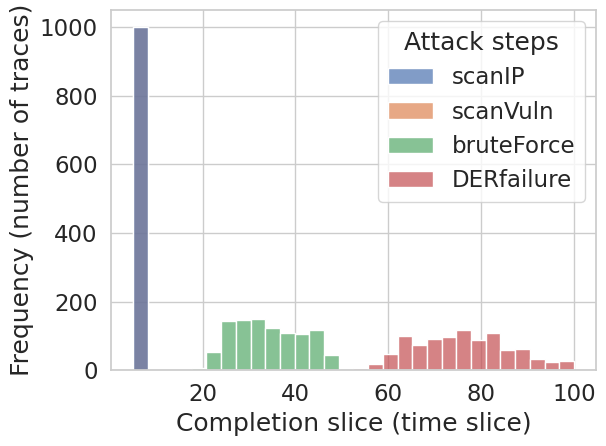

In [17]:
sns.set(font_scale=1.5)
sns.set_style("whitegrid")
ax = sns.histplot(data=distDf_melted, x='completion_time', hue='nodeId', bins=30, 
             palette="deep", alpha=0.7, common_norm=False, 
             multiple="layer")
plt.xlabel("Completion slice (time slice)")
plt.ylabel("Frequency (number of traces)")
#plt.title("Distribution of completion slices per attack step")
ax.get_legend().set_title("Attack steps")
plt.tight_layout() 
plt.savefig("plots/completion_slice_distribution.png", bbox_inches='tight')

In [11]:
# Compute the entropy for all nodes
distDict = {}
for nodeId in rawNodeIds:
    # Just take the columns that start with the target node name
    nodeCols = [col for col in df.columns if col.startswith(nodeId)]
    nodeData = df[nodeCols]
    firstCompletionData = []
    for i in range(0, len(nodeData)):
        firstCompletion = nodeData.iloc[i].value_counts()["N"] + 1
        firstCompletionData.append(firstCompletion if firstCompletion <= numSlices else np.nan)
    distDict[nodeId] = firstCompletionData
distDf = pd.DataFrame(distDict)  

entropyDict = {}
for col in distDf.columns:
    counts = distDf[col].value_counts(dropna=True)
    probabilities = counts / counts.sum()
    entropy = stats.entropy(probabilities, base=2)
    entropyDict[col] = entropy
# Sort by entropy value
entropyDict = dict(sorted(entropyDict.items(), key=lambda item: item[1], reverse=False))
print("Entropy values for all nodes:")
for nodeId, entropy in entropyDict.items():
    print(f"{nodeId}: {entropy:.3f}")

# Compute average entropy for target nodes and standard deviation
targetEntropies = [entropyDict[nodeId] for nodeId in targetNodes]
avgEntropy = np.mean(targetEntropies)
stdEntropy = np.std(targetEntropies)
print(f"Average entropy for target nodes: {avgEntropy:.3f} ± {stdEntropy:.3f}")

Entropy values for all nodes:
historian_scanVuln: 1.000
DMZ_scanIP: 1.000
workStation_compromise: 1.000
historian_remoteSrvc: 3.045
historianServer_NodeOR1: 3.156
historianServer_shell: 3.156
historianServer_remoteShellAND: 3.888
historianServer_addSSHkey: 3.888
tomcatWebServer_bruteForce: 4.806
historianServer_remoteShell: 4.903
MMSserver1_AITM: 5.349
MMSserver1_unauthCmdMsg: 5.349
MMSclient1_credAcc: 5.349
IED1_DERfailure: 5.349
MMSclient1_AND52: 5.349
MMSserver1_NodeAND23: 5.349
MMSserver1_spoofRepMsg: 5.349
MMSclient1_unsecCred: 5.372
MMSclient1_modAuthProc: 5.387
stationComputer_shell: 5.456
virtualEng_escapeHost: 5.469
Average entropy for target nodes: 3.039 ± 2.048


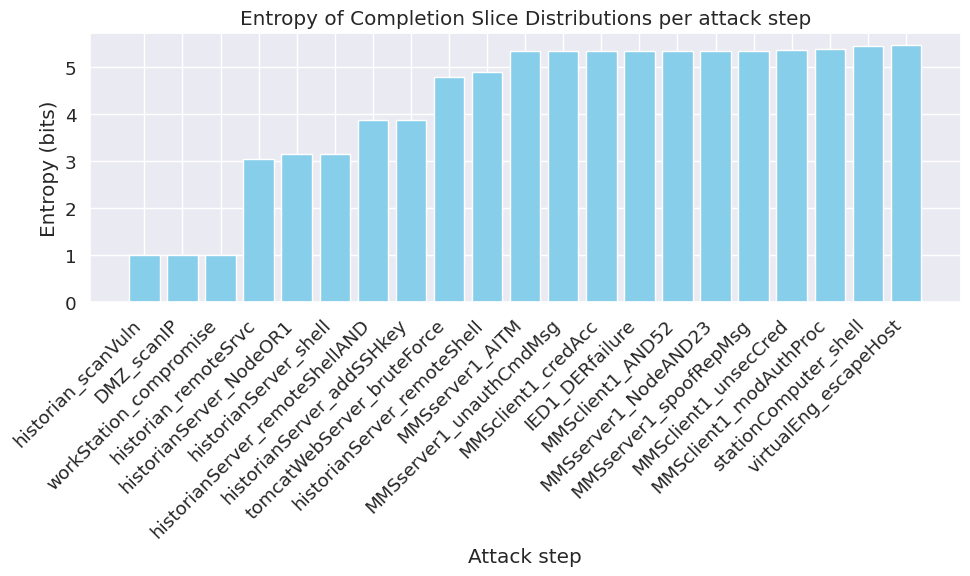

In [12]:
# Plot entropy values
plt.figure(figsize=(10, 6))
plt.bar(entropyDict.keys(), entropyDict.values(), color='skyblue')
plt.xlabel("Attack step")
plt.ylabel("Entropy (bits)")
plt.title("Entropy of Completion Slice Distributions per attack step")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()